# Data Cleaning, Exploratory Analysis, and Feature Engineering

This notebook prepares the Food.com Recipes and User Interactions data for downstream collaborative filtering and Bayesian recommendation modeling. It documents the main cleaning decisions, summarizes the interaction structure, explores recipe characteristics, and produces an interpretable recipe-feature table.

## 1. Setup

In [1]:
from pathlib import Path
import ast
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = PROJECT_ROOT / "Data"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"
PROCESSED_DIR = DATA_DIR / "processed"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

## 2. Load and Inspect Data

In [2]:
recipes = pd.read_csv(DATA_DIR / "RAW_recipes.csv")
interactions = pd.read_csv(DATA_DIR / "RAW_interactions.csv")

print(f"Recipes: {recipes.shape[0]:,} rows × {recipes.shape[1]} columns")
print(f"Interactions: {interactions.shape[0]:,} rows × {interactions.shape[1]} columns")

display(recipes.head())
display(interactions.head())

Recipes: 231,637 rows × 12 columns
Interactions: 1,132,367 rows × 5 columns


,name,id,minutes,contributor_id,submitted,tags,nutrition,n_steps,steps,description,ingredients,n_ingredients
0,arriba baked winter squash mexican style,137739,55,47892,2005-09-16,"['60-minutes-or-less', 'time-to-make', 'course...","[51.5, 0.0, 13.0, 0.0, 2.0, 0.0, 4.0]",11,"['make a choice and proceed with recipe', 'dep...",autumn is my favorite time of year to cook! th...,"['winter squash', 'mexican seasoning', 'mixed ...",7
1,a bit different breakfast pizza,31490,30,26278,2002-06-17,"['30-minutes-or-less', 'time-to-make', 'course...","[173.4, 18.0, 0.0, 17.0, 22.0, 35.0, 1.0]",9,"['preheat oven to 425 degrees f', 'press dough...",this recipe calls for the crust to be prebaked...,"['prepared pizza crust', 'sausage patty', 'egg...",6
2,all in the kitchen chili,112140,130,196586,2005-02-25,"['time-to-make', 'course', 'preparation', 'mai...","[269.8, 22.0, 32.0, 48.0, 39.0, 27.0, 5.0]",6,"['brown ground beef in large pot', 'add choppe...",this modified version of 'mom's' chili was a h...,"['ground beef', 'yellow onions', 'diced tomato...",13
3,alouette potatoes,59389,45,68585,2003-04-14,"['60-minutes-or-less', 'time-to-make', 'course...","[368.1, 17.0, 10.0, 2.0, 14.0, 8.0, 20.0]",11,['place potatoes in a large pot of lightly sal...,"this is a super easy, great tasting, make ahea...","['spreadable cheese with garlic and herbs', 'n...",11
4,amish tomato ketchup for canning,44061,190,41706,2002-10-25,"['weeknight', 'time-to-make', 'course', 'main-...","[352.9, 1.0, 337.0, 23.0, 3.0, 0.0, 28.0]",5,['mix all ingredients& boil for 2 1 / 2 hours ...,my dh's amish mother raised him on this recipe...,"['tomato juice', 'apple cider vinegar', 'sugar...",8


,user_id,recipe_id,date,rating,review
0,38094,40893,2003-02-17,4,Great with a salad. Cooked on top of stove for...
1,1293707,40893,2011-12-21,5,"So simple, so delicious! Great for chilly fall..."
2,8937,44394,2002-12-01,4,This worked very well and is EASY. I used not...
3,126440,85009,2010-02-27,5,I made the Mexican topping and took it to bunk...
4,57222,85009,2011-10-01,5,"Made the cheddar bacon topping, adding a sprin..."


In [3]:
overview = pd.DataFrame({
    "dataset": ["recipes", "interactions"],
    "rows": [len(recipes), len(interactions)],
    "columns": [recipes.shape[1], interactions.shape[1]],
    "duplicate_rows": [recipes.duplicated().sum(), interactions.duplicated().sum()],
})
overview

,dataset,rows,columns,duplicate_rows
0,recipes,231637,12,0
1,interactions,1132367,5,0


In [4]:
missing_summary = pd.concat(
    {
        "recipes": pd.DataFrame({
            "missing_count": recipes.isna().sum(),
            "missing_pct": (recipes.isna().mean() * 100).round(2),
        }),
        "interactions": pd.DataFrame({
            "missing_count": interactions.isna().sum(),
            "missing_pct": (interactions.isna().mean() * 100).round(2),
        }),
    },
    names=["dataset", "column"],
)
missing_summary

missing_count  missing_pct
dataset      column                                    
recipes      name                        1         0.00
             id                          0         0.00
             minutes                     0         0.00
             contributor_id              0         0.00
             submitted                   0         0.00
             tags                        0         0.00
             nutrition                   0         0.00
             n_steps                     0         0.00
             steps                       0         0.00
             description              4979         2.15
             ingredients                 0         0.00
             n_ingredients               0         0.00
interactions user_id                     0         0.00
             recipe_id                   0         0.00
             date                        0         0.00
             rating                      0         0.00
             review                    169         0.01

In [5]:
print("Duplicate recipe IDs:", recipes["id"].duplicated().sum())
print("Rating values:", sorted(interactions["rating"].unique()))

Duplicate recipe IDs: 0
Rating values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


### Initial data-quality findings

The datasets contain no fully duplicated rows and no duplicated recipe IDs. Missingness is limited: the main gap is in recipe descriptions, while recipe names and interaction reviews have only a small number of missing values. Ratings include `0` in addition to the explicit 1–5 scale, so zero-coded interactions require separate investigation before modeling.

## 3. Data Cleaning

In [6]:
recipes_clean = recipes.copy()
interactions_clean = interactions.copy()

recipes_clean["submitted"] = pd.to_datetime(recipes_clean["submitted"], errors="coerce")
interactions_clean["date"] = pd.to_datetime(interactions_clean["date"], errors="coerce")

recipes_clean["name"] = recipes_clean["name"].fillna("Unknown Recipe")

### 3.1 Zero-coded ratings

In [7]:
zero_ratings = interactions_clean.loc[interactions_clean["rating"] == 0]

zero_rating_summary = pd.Series({
    "zero_ratings": len(zero_ratings),
    "pct_of_interactions": round(len(zero_ratings) / len(interactions_clean) * 100, 2),
    "with_review": zero_ratings["review"].notna().sum(),
    "without_review": zero_ratings["review"].isna().sum(),
})
zero_rating_summary

zero_ratings           60847.00
pct_of_interactions        5.37
with_review            60847.00
without_review             0.00
dtype: float64

In [8]:
display(
    zero_ratings.loc[zero_ratings["review"].notna(), ["rating", "review"]]
    .head(10)
)

,rating,review
6,0,"Just an observation, so I will not rate. I fo..."
12,0,Made my own buttermilk w/ vinegar and milk. U...
23,0,This is a very good recipe. We also want to c...
39,0,i made it and it was amazing
56,0,"I used half cream and half 1% milk, added anot..."
63,0,FABULOUS!<br/><br/>I could not afford any of t...
66,0,Awesome chowder! I used both canned and imitat...
67,0,Do you have cook the potatoes beforehand?
119,0,Loved this salsa flavored meatloaf...tang is a...
134,0,There is no cooking temp?????? Love this recip...


Zero-coded interactions account for about 5.37% of the interaction data. Inspection shows that these records include written reviews, including clearly positive comments, so `0` is not treated as a true zero-star preference. Zero-coded interactions are retained in the general interaction data but excluded from analyses and models that require explicit 1–5 ratings.

In [9]:
ratings_clean = interactions_clean.loc[
    interactions_clean["rating"].between(1, 5)
].copy()

print(f"All interactions: {len(interactions_clean):,}")
print(f"Explicit ratings (1–5): {len(ratings_clean):,}")
print(f"Excluded zero-coded interactions: {len(interactions_clean) - len(ratings_clean):,}")

All interactions: 1,132,367
Explicit ratings (1–5): 1,071,520
Excluded zero-coded interactions: 60,847


### 3.2 Preparation-time anomalies

In [10]:
recipes_clean[["minutes", "n_steps", "n_ingredients"]].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

,minutes,n_steps,n_ingredients
count,2.316370e+05,231637.00,231637.00
mean,9.398550e+03,9.77,9.05
std,4.461963e+06,6.00,3.73
min,0.000000e+00,0.00,1.00
50%,4.000000e+01,9.00,9.00
75%,6.500000e+01,12.00,11.00
90%,1.350000e+02,17.00,14.00
95%,2.550000e+02,21.00,16.00
99%,9.039200e+02,30.00,20.00
max,2.147484e+09,145.00,43.00


In [11]:
display(
    recipes_clean[["name", "id", "minutes", "n_steps", "n_ingredients"]]
    .sort_values("minutes", ascending=False)
    .head(10)
)

print("Zero-minute recipes:", (recipes_clean["minutes"] == 0).sum())
print(
    "32-bit sentinel-like value count:",
    (recipes_clean["minutes"] == 2_147_483_647).sum(),
)

,name,id,minutes,n_steps,n_ingredients
144074,no bake granola balls,261647,2147483647,9,8
109624,how to preserve a husband,447963,1051200,9,2
106563,homemade fruit liquers,291571,288000,12,3
38116,celtic druid s honey mead meade metheglin,216215,259260,18,7
106963,homemade vanilla,425681,259205,9,2
155044,peach brandy,98912,216015,9,4
5497,angelica liqueur,70551,201610,7,7
177906,rumtopf,12931,187200,16,8
170999,raspberry liqueur,172114,172810,7,3
53721,cinnamon extract,153634,172800,5,2


Zero-minute recipes: 1094
32-bit sentinel-like value count: 1


In [12]:
invalid_minutes = (
    (recipes_clean["minutes"] <= 0)
    | (recipes_clean["minutes"] == 2_147_483_647)
)

recipes_clean.loc[invalid_minutes, "minutes"] = np.nan

print("Preparation times set to missing:", invalid_minutes.sum())
print("Missing preparation times after cleaning:", recipes_clean["minutes"].isna().sum())

Preparation times set to missing: 1095
Missing preparation times after cleaning: 1095


Zero-minute recipes are treated as having unavailable preparation time because many contain nontrivial cooking instructions. The value `2,147,483,647` minutes is also treated as invalid because it matches the maximum signed 32-bit integer and is implausible as a true duration. Other long preparation times are retained because aging, fermenting, preserving, and similar recipes can legitimately span days or months.

### 3.3 Parse structured recipe fields

In [13]:
NUTRITION_COLS = [
    "calories",
    "total_fat_pct",
    "sugar_pct",
    "sodium_pct",
    "protein_pct",
    "saturated_fat_pct",
    "carbohydrates_pct",
]

recipes_clean["tags_list"] = recipes_clean["tags"].apply(ast.literal_eval)
recipes_clean["ingredients_list"] = recipes_clean["ingredients"].apply(ast.literal_eval)

nutrition_values = recipes_clean["nutrition"].apply(ast.literal_eval)
nutrition_df = pd.DataFrame(
    nutrition_values.tolist(),
    columns=NUTRITION_COLS,
    index=recipes_clean.index,
)

recipes_clean[NUTRITION_COLS] = nutrition_df
recipes_clean["nutrition_valid"] = recipes_clean["calories"] > 0

In [14]:
cleaning_validation = pd.Series({
    "recipes": len(recipes_clean),
    "explicit_ratings": len(ratings_clean),
    "missing_recipe_names": recipes_clean["name"].isna().sum(),
    "missing_minutes": recipes_clean["minutes"].isna().sum(),
    "duplicate_recipe_ids": recipes_clean["id"].duplicated().sum(),
    "duplicate_interaction_rows": interactions_clean.duplicated().sum(),
    "min_explicit_rating": ratings_clean["rating"].min(),
    "max_explicit_rating": ratings_clean["rating"].max(),
})
cleaning_validation

recipes                        231637
explicit_ratings              1071520
missing_recipe_names                0
missing_minutes                  1095
duplicate_recipe_ids                0
duplicate_interaction_rows          0
min_explicit_rating                 1
max_explicit_rating                 5
dtype: int64

## 4. Exploratory Data Analysis

### 4.1 Rating distribution

In [15]:
rating_counts = ratings_clean["rating"].value_counts().sort_index()
rating_summary = pd.DataFrame({
    "count": rating_counts,
    "percent": (rating_counts / rating_counts.sum() * 100).round(2),
})
rating_summary

,count,percent
rating,,
1,12818,1.20
2,14123,1.32
3,40855,3.81
4,187360,17.49
5,816364,76.19


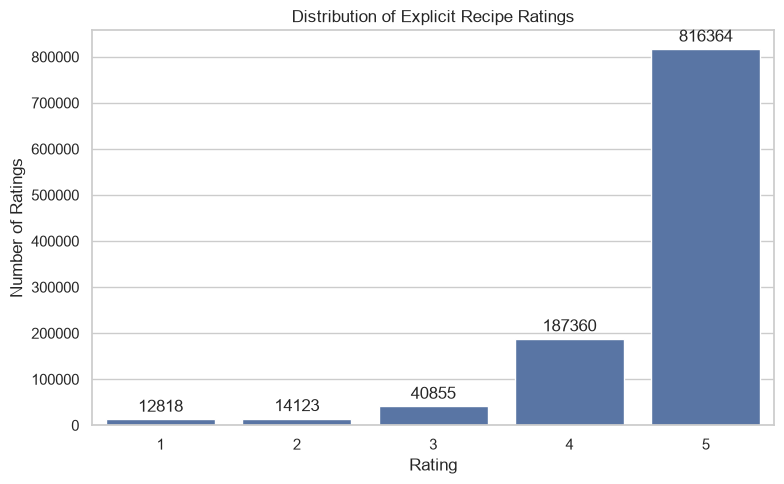

In [16]:
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=rating_counts.index, y=rating_counts.values)

for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", padding=3)

plt.title("Distribution of Explicit Recipe Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Ratings are strongly concentrated at the upper end of the scale. Ratings of 4 and 5 account for roughly 94% of explicit feedback, with rating 5 alone representing about 76%. This imbalance means overall predictive accuracy can be misleading if a model simply favors high ratings.

### 4.2 User and recipe sparsity

In [17]:
user_activity = ratings_clean.groupby("user_id").size()
recipe_activity = ratings_clean.groupby("recipe_id").size()

sparsity_summary = pd.DataFrame({
    "users": pd.Series({
        "unique_entities": user_activity.size,
        "median_ratings": user_activity.median(),
        "one_rating": (user_activity == 1).sum(),
        "fewer_than_5": (user_activity < 5).sum(),
        "at_least_10": (user_activity >= 10).sum(),
        "max_ratings": user_activity.max(),
    }),
    "recipes": pd.Series({
        "unique_entities": recipe_activity.size,
        "median_ratings": recipe_activity.median(),
        "one_rating": (recipe_activity == 1).sum(),
        "fewer_than_5": (recipe_activity < 5).sum(),
        "at_least_10": (recipe_activity >= 10).sum(),
        "max_ratings": recipe_activity.max(),
    }),
})
sparsity_summary

,users,recipes
unique_entities,196098.0,226590.0
median_ratings,1.0,2.0
one_rating,140318.0,91698.0
fewer_than_5,174080.0,175612.0
at_least_10,12035.0,20060.0
max_ratings,7665.0,1496.0


In [18]:
user_sparsity_pct = pd.Series({
    "1 rating": (user_activity == 1).mean() * 100,
    "fewer than 5 ratings": (user_activity < 5).mean() * 100,
    "at least 5 ratings": (user_activity >= 5).mean() * 100,
    "at least 10 ratings": (user_activity >= 10).mean() * 100,
    "at least 100 ratings": (user_activity >= 100).mean() * 100,
}).round(2)

user_sparsity_pct

1 rating                71.56
fewer than 5 ratings    88.77
at least 5 ratings      11.23
at least 10 ratings      6.14
at least 100 ratings     0.69
dtype: float64

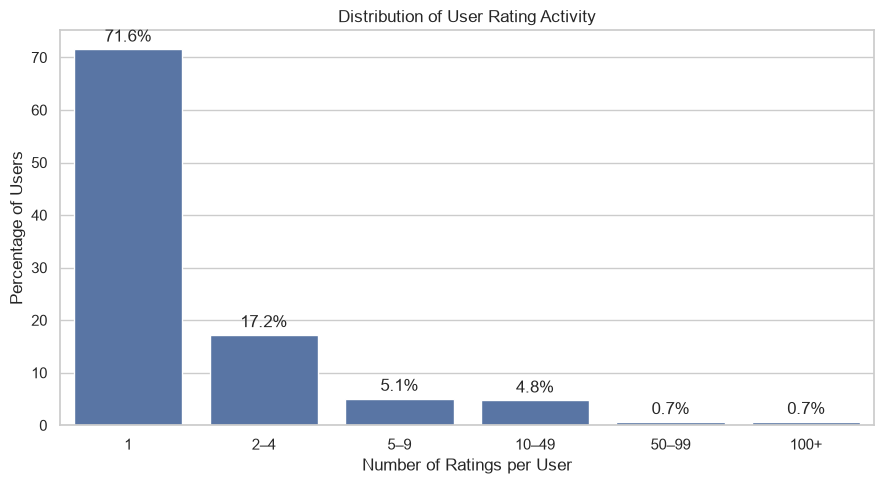

In [45]:
user_activity_groups = pd.Series({
    "1": (user_activity == 1).sum(),
    "2–4": user_activity.between(2, 4).sum(),
    "5–9": user_activity.between(5, 9).sum(),
    "10–49": user_activity.between(10, 49).sum(),
    "50–99": user_activity.between(50, 99).sum(),
    "100+": (user_activity >= 100).sum()
})

user_activity_pct = user_activity_groups / user_activity.size * 100

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=user_activity_pct.index,
    y=user_activity_pct.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Distribution of User Rating Activity")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Percentage of Users")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ratings_per_user.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

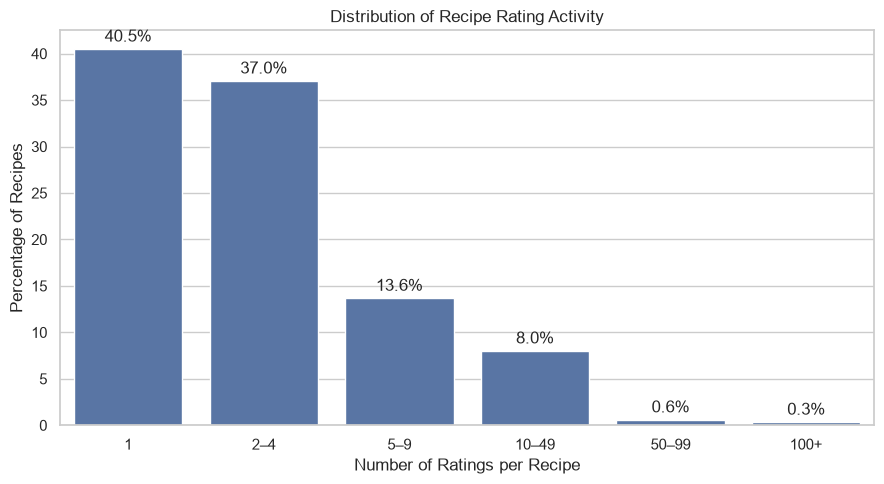

In [47]:
recipe_activity_groups = pd.Series({
    "1": (recipe_activity == 1).sum(),
    "2–4": recipe_activity.between(2, 4).sum(),
    "5–9": recipe_activity.between(5, 9).sum(),
    "10–49": recipe_activity.between(10, 49).sum(),
    "50–99": recipe_activity.between(50, 99).sum(),
    "100+": (recipe_activity >= 100).sum()
})

recipe_activity_pct = recipe_activity_groups / recipe_activity.size * 100

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    x=recipe_activity_pct.index,
    y=recipe_activity_pct.values
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.title("Distribution of Recipe Rating Activity")
plt.xlabel("Number of Ratings per Recipe")
plt.ylabel("Percentage of Recipes")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "ratings_per_recipe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The interaction matrix is highly sparse. The median user has only one explicit rating, and most users have fewer than five ratings. Recipe evidence is also limited: the median rated recipe has only two ratings. This is a central motivation for Bayesian preference updating because uncertainty should be higher when user or recipe evidence is limited.

### 4.3 Preparation time and recipe complexity

In [19]:
recipe_characteristics = recipes_clean[
    ["minutes", "n_ingredients", "n_steps"]
].describe(percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]).round(2)

recipe_characteristics

,minutes,n_ingredients,n_steps
count,230542.00,231637.00,231637.00
mean,128.25,9.05,9.77
std,2953.31,3.73,6.00
min,1.00,1.00,0.00
50%,40.00,9.00,9.00
75%,65.00,11.00,12.00
90%,135.00,14.00,17.00
95%,255.00,16.00,21.00
99%,920.00,20.00,30.00
max,1051200.00,43.00,145.00


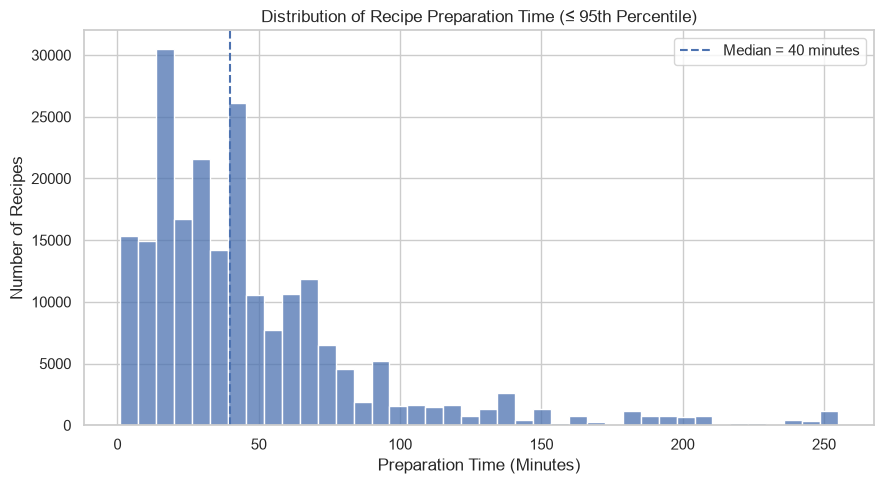

In [20]:
minutes_95 = recipes_clean["minutes"].quantile(0.95)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=recipes_clean.loc[recipes_clean["minutes"] <= minutes_95],
    x="minutes",
    bins=40,
)
plt.axvline(
    recipes_clean["minutes"].median(),
    linestyle="--",
    label=f"Median = {recipes_clean['minutes'].median():.0f} minutes",
)
plt.title("Distribution of Recipe Preparation Time (≤ 95th Percentile)")
plt.xlabel("Preparation Time (Minutes)")
plt.ylabel("Number of Recipes")
plt.legend()
plt.tight_layout()
plt.show()

Correlation between ingredients and steps: 0.428


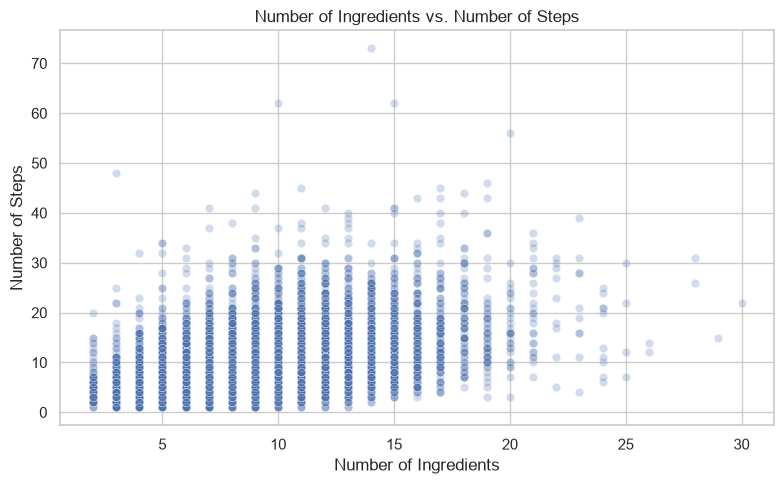

In [21]:
complexity_corr = recipes_clean[["n_ingredients", "n_steps"]].corr().iloc[0, 1]
print(f"Correlation between ingredients and steps: {complexity_corr:.3f}")

recipe_sample = recipes_clean.sample(n=10_000, random_state=42)

plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=recipe_sample,
    x="n_ingredients",
    y="n_steps",
    alpha=0.25,
)
plt.title("Number of Ingredients vs. Number of Steps")
plt.xlabel("Number of Ingredients")
plt.ylabel("Number of Steps")
plt.tight_layout()
plt.show()

Preparation time is strongly right-skewed: the median recipe takes about 40 minutes, while a small number of recipes require much longer periods. Ingredient count and step count are moderately positively related (approximately 0.43), suggesting that they capture related but distinct aspects of recipe complexity.

### 4.4 Nutritional characteristics

In [22]:
nutrition_summary = recipes_clean[NUTRITION_COLS].describe(
    percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

nutrition_summary

,calories,total_fat_pct,sugar_pct,sodium_pct,protein_pct,saturated_fat_pct,carbohydrates_pct
count,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00,231637.00
mean,473.94,36.08,84.30,30.15,34.68,45.59,15.56
std,1189.71,77.80,800.08,131.96,58.47,98.24,81.82
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,313.40,20.00,25.00,14.00,18.00,23.00,9.00
75%,519.70,41.00,68.00,33.00,51.00,52.00,16.00
90%,843.60,73.00,160.00,61.00,83.00,98.00,28.00
95%,1268.72,112.00,269.00,90.00,107.00,147.00,43.00
99%,3516.96,302.00,1141.64,219.00,188.00,404.00,154.00
max,434360.20,17183.00,362729.00,29338.00,6552.00,10395.00,36098.00


In [23]:
print("Zero-calorie recipes:", (recipes_clean["calories"] == 0).sum())

display(
    recipes_clean.loc[
        recipes_clean["calories"] == 0,
        ["name", "calories", "ingredients", "nutrition"],
    ].head(10)
)

Zero-calorie recipes: 53


,name,calories,ingredients,nutrition
4707,amazing stain remover,0.0,"['cold water', 'laundry detergent', 'bleach']","[0.0, 0.0, 0.0, 3.0, 0.0, 0.0, 0.0]"
10758,authentic german black bread schwarzbrot,0.0,"['water', 'sourdough starter', 'rye berries', ...","[0.0, 0.0, 0.0, 145.0, 0.0, 0.0, 0.0]"
19827,bee or wasp sting soother,0.0,"['baking soda', 'water']","[0.0, 0.0, 0.0, 104.0, 0.0, 0.0, 0.0]"
28942,brining solution for poultry and meat,0.0,"['cold water', 'kosher salt']","[0.0, 0.0, 0.0, 295.0, 0.0, 0.0, 0.0]"
37985,cedar planked anything,0.0,"['cedar plank', 'water', 'salt', 'plastic wrap...","[0.0, 0.0, 0.0, 293.0, 0.0, 0.0, 0.0]"
56738,collards southern style,0.0,"['collard greens', 'ham hock', 'salt', 'pepper...","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0]"
72469,dishwasher detergent,0.0,"['cleaner', 'baking soda', 'lemons']","[0.0, 0.0, 0.0, 77.0, 0.0, 0.0, 0.0]"
73643,dried morel mushrooms,0.0,"['morel', 'water', 'salt']","[0.0, 0.0, 0.0, 4720.0, 0.0, 0.0, 0.0]"
73763,dry aged steak at home,0.0,"['rib eye steak', 'coarse sea salt']","[0.0, 0.0, 0.0, 72.0, 0.0, 0.0, 0.0]"
77164,easy microwave popcorn,0.0,"['popcorn', 'salt']","[0.0, 0.0, 0.0, 6.0, 0.0, 0.0, 0.0]"


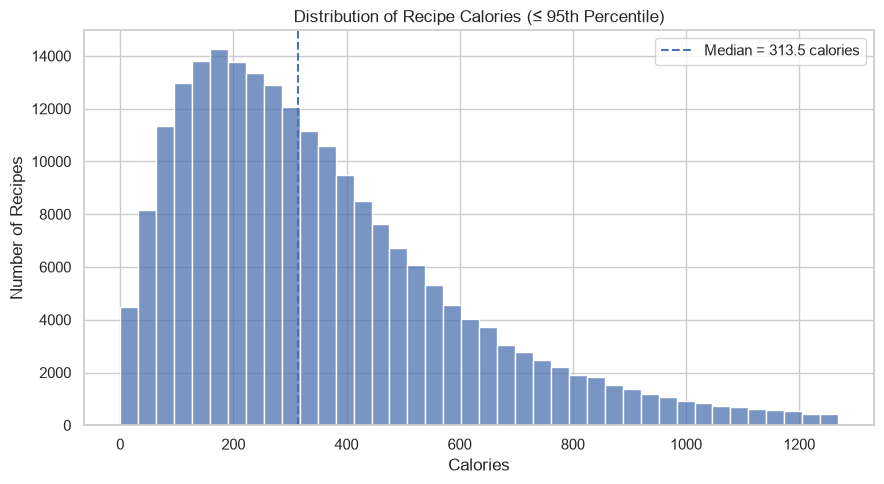

In [24]:
nutrition_clean = recipes_clean.loc[recipes_clean["nutrition_valid"]].copy()
calories_95 = nutrition_clean["calories"].quantile(0.95)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=nutrition_clean.loc[nutrition_clean["calories"] <= calories_95],
    x="calories",
    bins=40,
)
plt.axvline(
    nutrition_clean["calories"].median(),
    linestyle="--",
    label=f"Median = {nutrition_clean['calories'].median():.1f} calories",
)
plt.title("Distribution of Recipe Calories (≤ 95th Percentile)")
plt.xlabel("Calories")
plt.ylabel("Number of Recipes")
plt.legend()
plt.tight_layout()
plt.show()

Nutrition variables are strongly right-skewed. Zero-calorie records include both non-food entries and foods that would normally contain calories, so they are retained in the recipe table but excluded from nutrition-specific summaries through the `nutrition_valid` flag. Extreme positive values are retained because serving size and batch size are not consistently available.

### 4.5 Tags and ingredients

In [25]:
tag_counts = Counter(
    tag
    for tags in recipes_clean["tags_list"]
    for tag in tags
)
top_tags = pd.DataFrame(tag_counts.most_common(20), columns=["tag", "count"])
top_tags

,tag,count
0,preparation,230546
1,time-to-make,225326
2,course,218148
3,main-ingredient,170446
4,dietary,165091
5,easy,126062
6,occasion,114145
7,cuisine,91165
8,low-in-something,85776
9,main-dish,71786


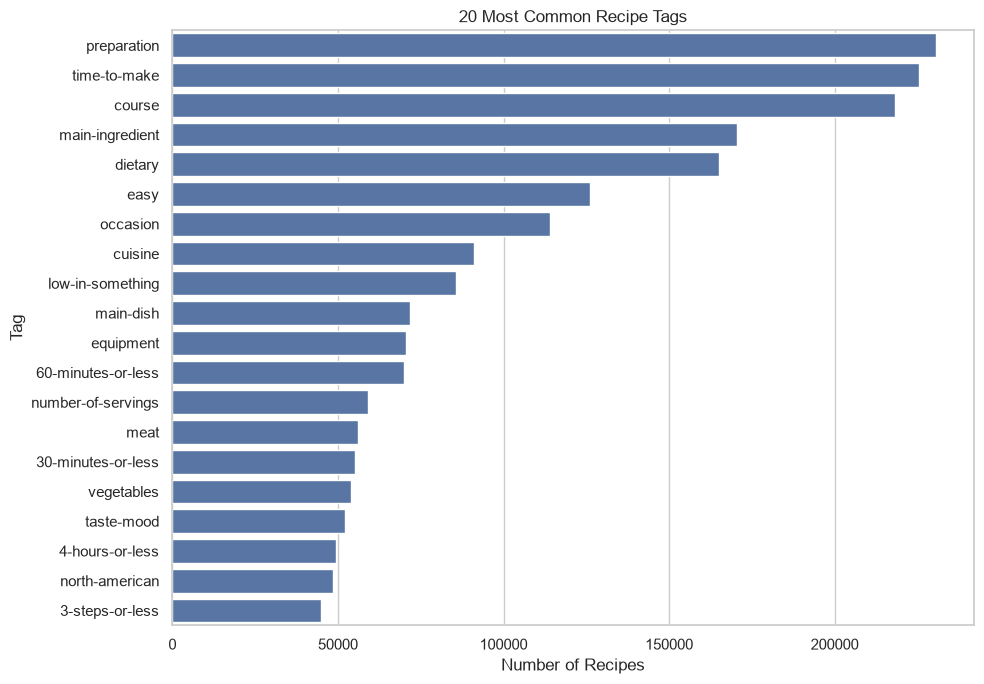

In [26]:
plt.figure(figsize=(10, 7))
sns.barplot(data=top_tags, x="count", y="tag")
plt.title("20 Most Common Recipe Tags")
plt.xlabel("Number of Recipes")
plt.ylabel("Tag")
plt.tight_layout()
plt.show()

In [27]:
ingredient_counts = Counter(
    ingredient
    for ingredients in recipes_clean["ingredients_list"]
    for ingredient in ingredients
)
top_ingredients = pd.DataFrame(
    ingredient_counts.most_common(20),
    columns=["ingredient", "count"],
)
top_ingredients

,ingredient,count
0,salt,85746
1,butter,54975
2,sugar,44535
3,onion,39065
4,water,34914
5,eggs,33761
6,olive oil,32822
7,flour,26266
8,milk,25786
9,garlic cloves,25748


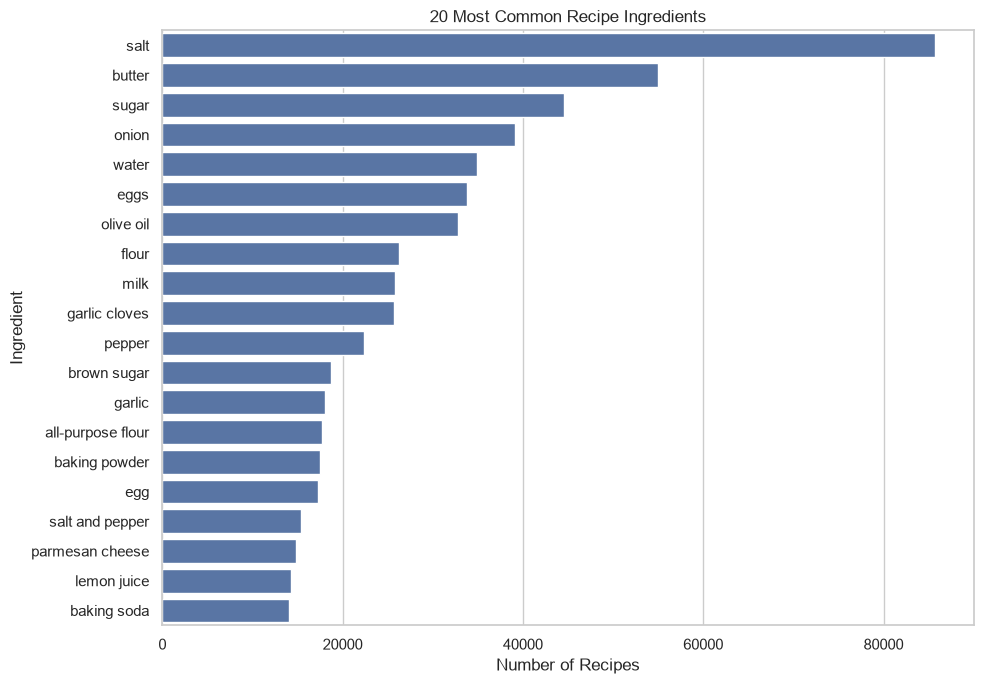

In [28]:
plt.figure(figsize=(10, 7))
sns.barplot(data=top_ingredients, x="count", y="ingredient")
plt.title("20 Most Common Recipe Ingredients")
plt.xlabel("Number of Recipes")
plt.ylabel("Ingredient")
plt.tight_layout()
plt.show()

The most common tags are broad organizational labels, while more specific cuisine, dietary, meal-type, and preparation tags are more useful for personalization. Ingredient counts are dominated by pantry staples and reveal some naming redundancy, such as singular/plural variants; therefore, the primary engineered feature set relies on interpretable tag groups rather than raw ingredient one-hot encoding.

### 4.6 Recipe characteristics and rating behavior

In [29]:
rating_recipe = ratings_clean.merge(
    recipes_clean[
        ["id", "minutes", "n_steps", "n_ingredients", "calories", "protein_pct"]
    ],
    left_on="recipe_id",
    right_on="id",
    how="left",
)

print("Ratings without matching recipes:", rating_recipe["id"].isna().sum())

rating_recipe.groupby("rating")[
    ["minutes", "n_ingredients", "n_steps", "calories"]
].median().round(2)

Ratings without matching recipes: 0


,minutes,n_ingredients,n_steps,calories
rating,,,,
1,40.0,8.0,9.0,315.7
2,41.5,9.0,8.0,316.2
3,40.0,9.0,8.0,316.1
4,40.0,9.0,8.0,309.6
5,40.0,9.0,8.0,312.2


Median preparation time, ingredient count, step count, and calories vary little across rating levels. These simple recipe characteristics do not strongly distinguish high- from low-rated recipes, which supports a personalized approach rather than assuming that one recipe profile is universally preferred.

### 4.7 Rating evidence and uncertainty

In [30]:
recipe_rating_stats = (
    ratings_clean.groupby("recipe_id")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count"),
    )
    .reset_index()
)

recipe_evidence = pd.Series({
    "1 rating": (recipe_rating_stats["rating_count"] == 1).sum(),
    "fewer than 5 ratings": (recipe_rating_stats["rating_count"] < 5).sum(),
    "at least 10 ratings": (recipe_rating_stats["rating_count"] >= 10).sum(),
    "at least 100 ratings": (recipe_rating_stats["rating_count"] >= 100).sum(),
})
recipe_evidence

1 rating                 91698
fewer than 5 ratings    175612
at least 10 ratings      20060
at least 100 ratings       711
dtype: int64

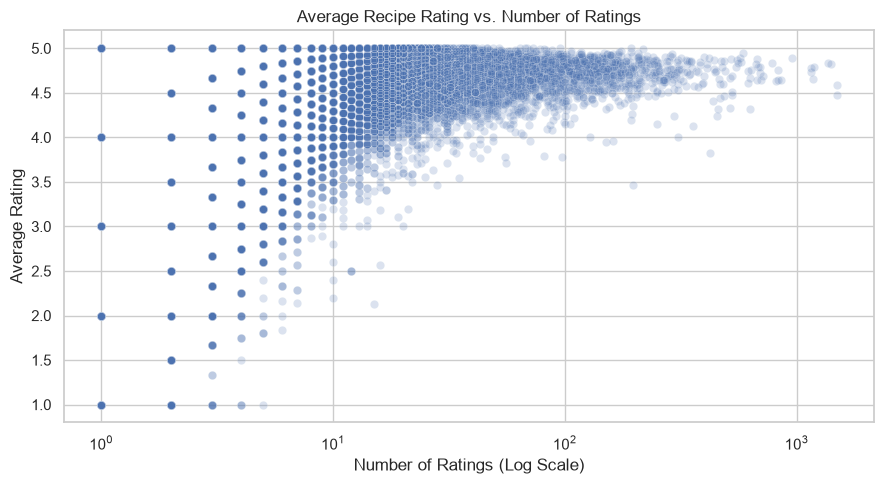

In [31]:
plt.figure(figsize=(9, 5))
sns.scatterplot(
    data=recipe_rating_stats,
    x="rating_count",
    y="mean_rating",
    alpha=0.20,
)
plt.xscale("log")
plt.title("Average Recipe Rating vs. Number of Ratings")
plt.xlabel("Number of Ratings (Log Scale)")
plt.ylabel("Average Rating")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "recipe_rating_vs_count.png", dpi=300, bbox_inches="tight")
plt.show()

Average ratings based on only a few observations vary across nearly the full rating scale, while highly rated recipes with many observations have much more stable averages. This illustrates why raw averages do not fully represent confidence: one 5-star rating and hundreds of ratings averaging near 5 should not be treated as equally certain.

### 4.8 User rating behavior

In [32]:
user_rating_stats = (
    ratings_clean.groupby("user_id")
    .agg(
        mean_rating=("rating", "mean"),
        rating_count=("rating", "count"),
    )
    .reset_index()
)

active_users = user_rating_stats.loc[user_rating_stats["rating_count"] >= 5]
active_users["mean_rating"].describe().round(2)

count    22018.00
mean         4.65
std          0.37
min          1.00
25%          4.49
50%          4.75
75%          4.93
max          5.00
Name: mean_rating, dtype: float64

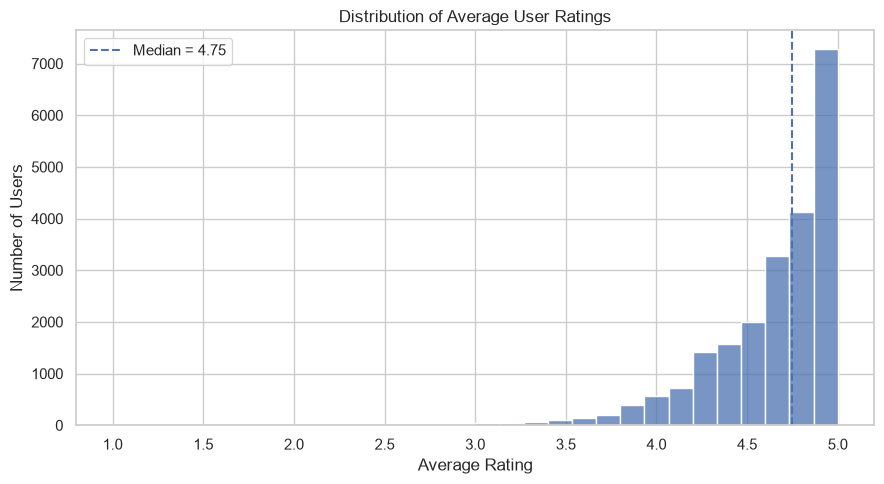

In [33]:
plt.figure(figsize=(9, 5))
sns.histplot(active_users["mean_rating"], bins=30)
plt.axvline(
    active_users["mean_rating"].median(),
    linestyle="--",
    label=f"Median = {active_users['mean_rating'].median():.2f}",
)
plt.title("Distribution of Average User Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Number of Users")
plt.legend()
plt.tight_layout()
plt.savefig(
    FIGURE_DIR / "user_average_rating_distribution.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Among users with at least five explicit ratings, average ratings are concentrated near the upper end of the scale, but user-level variation remains. A personalized model should therefore account for individual rating tendencies rather than interpreting identical numerical ratings as equally informative across all users.

## 5. Feature Engineering

The feature set emphasizes interpretable attributes that can support Bayesian preference updating: dietary preferences, meal types, cuisines, cooking-time categories, and nutrition levels.

In [34]:
DIETARY_FEATURES = {
    "is_vegetarian": "vegetarian",
    "is_vegan": "vegan",
    "is_gluten_free": "gluten-free",
    "is_low_carb": "low-carb",
    "is_low_fat": "low-fat",
    "is_healthy": "healthy",
}

MEAL_FEATURES = {
    "is_main_dish": "main-dish",
    "is_dessert": "desserts",
    "is_breakfast": "breakfast",
    "is_lunch": "lunch",
    "is_appetizer": "appetizers",
    "is_side_dish": "side-dishes",
    "is_snack": "snacks",
    "is_soup_stew": "soups-stews",
    "is_salad": "salads",
}

CUISINE_FEATURES = {
    "is_north_american": "north-american",
    "is_italian": "italian",
    "is_mexican": "mexican",
    "is_chinese": "chinese",
    "is_indian": "indian",
    "is_thai": "thai",
    "is_greek": "greek",
    "is_french": "french",
    "is_middle_eastern": "middle-eastern",
    "is_spanish": "spanish",
}

### 5.1 Candidate tag coverage

In [35]:
candidate_tags = {
    "dietary": [
        "vegetarian", "vegan", "gluten-free", "dairy-free",
        "low-carb", "low-fat", "healthy",
    ],
    "meal_type": [
        "main-dish", "desserts", "breakfast", "lunch", "appetizers",
        "side-dishes", "snacks", "soups-stews", "salads",
    ],
    "cuisine": [
        "north-american", "italian", "mexican", "chinese", "indian",
        "thai", "japanese", "greek", "french", "mediterranean",
        "middle-eastern", "spanish", "korean", "vietnamese",
    ],
}

tag_coverage = []
for group, tags in candidate_tags.items():
    for tag in tags:
        count = sum(tag in recipe_tags for recipe_tags in recipes_clean["tags_list"])
        tag_coverage.append({
            "group": group,
            "tag": tag,
            "count": count,
            "percent": round(count / len(recipes_clean) * 100, 2),
        })

tag_coverage = pd.DataFrame(tag_coverage)
tag_coverage

,group,tag,count,percent
0,dietary,vegetarian,35651,15.39
1,dietary,vegan,10012,4.32
2,dietary,gluten-free,5743,2.48
3,dietary,dairy-free,195,0.08
4,dietary,low-carb,42189,18.21
5,dietary,low-fat,22170,9.57
6,dietary,healthy,40340,17.42
7,meal_type,main-dish,71786,30.99
8,meal_type,desserts,43203,18.65
9,meal_type,breakfast,13655,5.89


The very sparse `dairy-free` tag is excluded as a standalone dietary feature. Cuisine indicators are limited to categories with approximately 1,000 or more recipes to reduce extreme sparsity. Meal-type features are retained because each has adequate representation. These indicators are not mutually exclusive; a recipe can belong to multiple tag groups.

In [36]:
def add_tag_features(df, feature_map):
    for column, tag in feature_map.items():
        df[column] = df["tags_list"].apply(lambda tags: int(tag in tags))
    return df


recipes_clean = add_tag_features(recipes_clean, DIETARY_FEATURES)
recipes_clean = add_tag_features(recipes_clean, MEAL_FEATURES)
recipes_clean = add_tag_features(recipes_clean, CUISINE_FEATURES)

dietary_cols = list(DIETARY_FEATURES)
meal_cols = list(MEAL_FEATURES)
cuisine_cols = list(CUISINE_FEATURES)

### 5.2 Cooking-time features

In [37]:
recipes_clean["time_bucket"] = pd.cut(
    recipes_clean["minutes"],
    bins=[0, 30, 60, 120, float("inf")],
    labels=["quick", "moderate", "long", "extended"],
    include_lowest=True,
)

TIME_FEATURES = {
    "is_quick": "quick",
    "is_moderate_time": "moderate",
    "is_long_time": "long",
    "is_extended_time": "extended",
}

for column, category in TIME_FEATURES.items():
    recipes_clean[column] = (recipes_clean["time_bucket"] == category).astype(int)

time_cols = list(TIME_FEATURES)

time_summary = pd.DataFrame({
    "count": recipes_clean["time_bucket"].value_counts().sort_index(),
    "percent": (
        recipes_clean["time_bucket"].value_counts(normalize=True).sort_index() * 100
    ).round(2),
})
time_summary

,count,percent
time_bucket,,
quick,97959,42.49
moderate,70077,30.40
long,36683,15.91
extended,25823,11.20


Cooking-time buckets are mutually exclusive and sufficiently represented: quick recipes are the largest group, while extended recipes remain common enough to support preference learning. Recipes with missing preparation time receive `0` for all four time indicators.

### 5.3 Nutrition features

In [38]:
nutrition_features = {}

for col in NUTRITION_COLS:
    q25 = recipes_clean[col].quantile(0.25)
    q75 = recipes_clean[col].quantile(0.75)
    level_col = f"{col}_level"

    recipes_clean[level_col] = pd.cut(
        recipes_clean[col],
        bins=[-float("inf"), q25, q75, float("inf")],
        labels=["low", "moderate", "high"],
        include_lowest=True,
    )

    feature_name = col.replace("_pct", "")
    nutrition_features[f"is_low_{feature_name}"] = (col, "low")
    nutrition_features[f"is_high_{feature_name}"] = (col, "high")

for feature, (col, level) in nutrition_features.items():
    recipes_clean[feature] = (
        recipes_clean[f"{col}_level"] == level
    ).astype(int)

nutrition_feature_cols = list(nutrition_features)

In [39]:
nutrition_feature_summary = pd.DataFrame({
    "count": recipes_clean[nutrition_feature_cols].sum(),
    "percent": (recipes_clean[nutrition_feature_cols].mean() * 100).round(2),
})
nutrition_feature_summary

,count,percent
is_low_calories,57945,25.02
is_high_calories,57909,25.00
is_low_total_fat,59942,25.88
is_high_total_fat,56611,24.44
is_low_sugar,59115,25.52
is_high_sugar,57492,24.82
is_low_sodium,62620,27.03
is_high_sodium,56111,24.22
is_low_protein,65042,28.08
is_high_protein,56651,24.46


Low/high nutrition indicators are defined using the 25th and 75th percentiles. Their prevalence is not exactly 25% because tied values at the quartile boundaries are assigned to the same category. This representation reduces sensitivity to extreme raw nutrition values while keeping the features interpretable.

### 5.4 Final feature dataset

In [40]:
final_feature_cols = (
    dietary_cols
    + meal_cols
    + cuisine_cols
    + time_cols
    + nutrition_feature_cols
)

recipe_features = recipes_clean[
    ["id", "name"] + final_feature_cols
].copy()

feature_validation = pd.Series({
    "recipes": len(recipe_features),
    "engineered_features": len(final_feature_cols),
    "missing_values": recipe_features.isna().sum().sum(),
    "duplicate_recipe_ids": recipe_features["id"].duplicated().sum(),
    "recipes_with_no_active_features": (
        recipe_features[final_feature_cols].sum(axis=1) == 0
    ).sum(),
})
feature_validation

recipes                            231637
engineered_features                    43
missing_values                          0
duplicate_recipe_ids                    0
recipes_with_no_active_features        10
dtype: int64

In [41]:
feature_prevalence = pd.DataFrame({
    "count": recipe_features[final_feature_cols].sum(),
    "percent": (recipe_features[final_feature_cols].mean() * 100).round(2),
})
feature_prevalence

,count,percent
is_vegetarian,35651,15.39
is_vegan,10012,4.32
is_gluten_free,5743,2.48
is_low_carb,42189,18.21
is_low_fat,22170,9.57
is_healthy,40340,17.42
is_main_dish,71786,30.99
is_dessert,43203,18.65
is_breakfast,13655,5.89
is_lunch,23800,10.27


The final feature table contains 231,637 recipes and 43 binary engineered features with no missing values or duplicate recipe IDs. Only a negligible number of recipes have no active engineered feature; these records are retained because collaborative-filtering information can still contribute in the hybrid recommender.

## 6. Save Model-Ready Data

In [42]:
explicit_ratings = ratings_clean[
    ["user_id", "recipe_id", "date", "rating", "review"]
].copy()

recipe_features.to_csv(PROCESSED_DIR / "recipe_features.csv", index=False)
explicit_ratings.to_csv(PROCESSED_DIR / "explicit_ratings.csv", index=False)

print(f"Saved recipe_features.csv: {recipe_features.shape}")
print(f"Saved explicit_ratings.csv: {explicit_ratings.shape}")

Saved recipe_features.csv: (231637, 45)
Saved explicit_ratings.csv: (1071520, 5)


The processed files are saved locally under `Data/processed/`. The `Data/` directory is intentionally excluded from Git version control, so the reproducible notebook and source modules—not the large generated CSV files—should be committed.

## 7. Reproducibility Check

In [43]:
import importlib
import sys

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.data.cleaning as cleaning
import src.features.recipe_features as recipe_feature_module

importlib.reload(cleaning)
importlib.reload(recipe_feature_module)

recipes_module_clean = cleaning.clean_recipes(recipes)
interactions_module_clean = cleaning.clean_interactions(interactions)
recipe_features_module = recipe_feature_module.build_recipe_features(recipes_clean)

module_validation = pd.Series({
    "explicit_interactions": len(interactions_module_clean),
    "rating_min": interactions_module_clean["rating"].min(),
    "rating_max": interactions_module_clean["rating"].max(),
    "missing_recipe_names": recipes_module_clean["name"].isna().sum(),
    "missing_recipe_minutes": recipes_module_clean["minutes"].isna().sum(),
    "feature_rows": recipe_features_module.shape[0],
    "feature_columns": recipe_features_module.shape[1],
    "feature_missing_values": recipe_features_module.isna().sum().sum(),
    "feature_duplicate_ids": recipe_features_module["id"].duplicated().sum(),
})
module_validation

explicit_interactions     1071520
rating_min                      1
rating_max                      5
missing_recipe_names            0
missing_recipe_minutes       1095
feature_rows               231637
feature_columns                45
feature_missing_values          0
feature_duplicate_ids           0
dtype: int64

## Key Findings

- Explicit ratings are heavily skewed toward 4–5 stars, so evaluation should account for rating imbalance.
- User and recipe interaction histories are highly sparse, creating substantial uncertainty and cold-start challenges.
- Simple recipe characteristics such as cooking time, ingredient count, steps, and calories do not strongly separate rating levels.
- Rating reliability varies substantially with the amount of evidence, supporting a Bayesian approach that represents uncertainty rather than relying only on raw averages.
- The final 43-feature recipe representation provides interpretable dietary, meal-type, cuisine, cooking-time, and nutrition signals for Bayesian preference updating and hybrid recommendation.